# Model Training Using XGBoost

## Overview

After completing data preprocessing, the processed dataset was used to train an **Extreme Gradient Boosting (XGBoost)** classifier to predict the **Relief Priority** of historical disaster events. The objective of the model is to classify each disaster into one of three priority levels (**Low**, **Medium**, or **High**) based on the engineered disaster severity features.

XGBoost was selected because it is a powerful ensemble learning algorithm that achieves high predictive performance through gradient boosting while incorporating regularization techniques to reduce overfitting.

---

## Prediction Function

XGBoost predicts the target variable by combining the outputs of multiple decision trees.

The prediction for an input feature vector is given by

$$
\hat{y}
=
\sum_{k=1}^{K}
f_k(\mathbf{x})
$$

where

- $\hat{y}$ = predicted score
- $K$ = total number of decision trees
- $f_k(\mathbf{x})$ = prediction from the $k^{th}$ decision tree

Since this project is a **multi-class classification** problem, the predicted scores are transformed into class probabilities using the **Softmax** function.

$$
P(y=i|\mathbf{x})
=
\frac{e^{\hat{y}_i}}
{\sum_{j=1}^{C}e^{\hat{y}_j}}
$$

where

- $C$ = number of classes
- $\hat{y}_i$ = predicted score for class $i$

The final prediction is obtained by selecting the class with the highest probability.

$$
\boxed{
\hat{c}
=
\arg\max_i
P(y=i|\mathbf{x})
}
$$

where

- $\hat{c}$ = predicted Relief Priority class.

---

## Objective Function

During training, XGBoost minimizes an objective function consisting of a prediction loss and a regularization term.

$$
\boxed{
Obj^{(t)}
=
\sum_{i=1}^{n}
l(y_i,\hat{y}_i)
+
\sum_{k=1}^{t}
\Omega(f_k)
}
$$

where

- $l(y_i,\hat{y}_i)$ = prediction loss
- $\Omega(f_k)$ = regularization term
- $t$ = current boosting iteration

The objective function ensures that the model not only produces accurate predictions but also avoids overfitting by controlling model complexity.

---

## Regularization Function

The complexity of each decision tree is measured using

$$
\boxed{
\Omega(f)
=
\gamma T
+
\frac{1}{2}\lambda
\sum_{j=1}^{T}
w_j^2
}
$$

where

- $T$ = number of leaf nodes
- $w_j$ = weight of the $j^{th}$ leaf
- $\gamma$ = penalty for creating additional leaves
- $\lambda$ = L2 regularization parameter

This regularization mechanism improves the model's ability to generalize to unseen disaster events.

---

## Loss Function

The model was trained using the **Multi-class Logarithmic Loss (Cross-Entropy Loss)** because the prediction task involves three disaster priority classes.

The loss function is defined as

$$
\boxed{
L
=
-
\frac{1}{N}
\sum_{i=1}^{N}
\sum_{c=1}^{C}
y_{ic}
\log(p_{ic})
}
$$

where

- $N$ = number of training samples
- $C$ = number of target classes
- $y_{ic}$ = actual class label
- $p_{ic}$ = predicted probability

The objective of model training is to minimize this loss.

---

## Gradient Boosting

Instead of building a single decision tree, XGBoost sequentially builds multiple trees. Each newly constructed tree learns the residual errors of the previous trees.

The prediction at iteration $t$ is computed as

$$
\boxed{
\hat{y}^{(t)}
=
\hat{y}^{(t-1)}
+
f_t(\mathbf{x})
}
$$

where

- $\hat{y}^{(t-1)}$ = prediction from previous trees
- $f_t(\mathbf{x})$ = prediction generated by the new tree

This iterative learning process gradually improves the predictive performance of the model.

---

## Model Configuration

The XGBoost classifier was initialized using the following configuration:

```python
model = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

model.fit(X_train, y_train)
```

where

- **Objective:** `multi:softmax`
- **Number of Classes:** `3`
- **Evaluation Metric:** `mlogloss`
- **Random State:** `42`

---

## Summary

The XGBoost classifier was trained to predict disaster relief priority using five engineered disaster severity features. During training, the algorithm sequentially constructed decision trees while minimizing the multi-class logarithmic loss and controlling model complexity through regularization. The resulting model is capable of classifying disaster events into **Low**, **Medium**, or **High** relief priority based on their estimated severity.

In [1]:
import pandas as pd
import numpy as np 
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier,plot_importance
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import joblib
import matplotlib.pyplot as plt



### 1.0 Preparing X and y

* Inputs or "X"= [ "disaster_type","affected_rate","homeless_rate","casualty_rate",
        "damage_rate",
        "duration_score"]
* target value or "y"= "relief_priority"

In [2]:
# loading processed datasets from proceesed folder:
preprocessed_df=pd.read_csv("../../data/preprocessed/preprocessed_dataset.csv")

In [3]:
preprocessed_df.head()

,disaster_id,disaster_location_id,geoname_id,precision_code,place_name,latitude,longitude,location_type_code,geoname_adm_code,geoname_adm_name,...,nearest_city,population,distance_km,casualty_rate,damage_rate,homeless_rate,affected_rate,duration,priority_score,relief_priority
0,1980-9364,1980-9364_1699597,1699597,1,Mindanao,8.00000,125.00000,ISL,6295630|6255147|PH|00,Earth|Asia|Philippines|Mindanao,...,Valencia,223620,14.762002,0.000000,0.000000,0.000000,0.029455,0.598684,0.070178,High
1,1980-314,1980-314_1688177,1688177,1,Santa Fe,16.20000,120.88333,ADM3,6295630|6255147|PH|02|1697456|1688177,Earth|Asia|Philippines|Cagayan Valley|Province...,...,Tayug,45476,24.102993,0.000356,0.000000,0.000000,0.000000,0.000000,0.000071,Low
2,1980-99,1980-99_7521297,7521297,4,Cagayan Valley,17.65667,121.73333,ADM1,6295630|6255147|PH|02,Earth|Asia|Philippines|Cagayan Valley,...,Tuguegarao,167297,4.833201,0.000195,0.073625,0.049927,0.039447,0.000000,0.033690,High
3,1980-99,1980-99_7521301,7521301,4,Ilocos,16.97917,120.52083,ADM1,6295630|6255147|PH|01,Earth|Asia|Philippines|Ilocos,...,Balaoan,40339,21.424243,0.000810,0.305343,0.207059,0.163596,0.000000,0.139720,High
4,1980-99,1980-99_7521305,7521305,4,Central Luzon,15.30714,120.79762,ADM1,6295630|6255147|PH|03,Earth|Asia|Philippines|Central Luzon,...,Concepcion,178549,15.379795,0.000183,0.068985,0.046780,0.036961,0.000000,0.031566,High


In [4]:
X=preprocessed_df[
    [
        "disaster_type",
        "affected_rate",
        "homeless_rate",
        "casualty_rate",
        "damage_rate",
        "duration"
    ]
]

y=preprocessed_df["relief_priority"]


### 1.1 Encoding Categorical Variables

Machine learning algorithms require numerical representations of categorical data before model training. In this project, two categorical variables were encoded:

1. **Disaster Type** (input feature)
2. **Relief Priority** (target variable)

Both variables were transformed into numerical labels using Scikit-learn's **LabelEncoder**.

---

#### Encoding the Input Feature

The **`disaster_type`** feature contains different categories of natural disasters, such as floods, earthquakes, tropical cyclones, and volcanic eruptions. Since these categories are represented as text, they were converted into unique numerical values.

For example,

| Disaster Type | Encoded Value |
|----------------|--------------:|
| Earthquake | 0 |
| Flood | 1 |
| Tropical Cyclone | 2 |
| Volcano | 3 |

The transformation was performed using:

```python
from sklearn.preprocessing import LabelEncoder

disaster_encoder = LabelEncoder()

preprocessed_df["disaster_type"] = disaster_encoder.fit_transform(
    preprocessed_df["disaster_type"]
)
```

---

#### Encoding the Target Variable

The **`relief_priority`** variable serves as the prediction target of the model. Since the XGBoost classifier requires numerical target labels, the three priority classes were encoded into integer values.

| Relief Priority | Encoded Value |
|-----------------|--------------:|
| Low | 0 |
| Medium | 1 |
| High | 2 |

The encoding process was implemented as follows:

```python
target_encoder = LabelEncoder()

y = target_encoder.fit_transform(
    preprocessed_df["relief_priority"]
)
```

The trained label encoder was saved for future inference to ensure that the same mapping is applied when predicting new disaster events.

```python
import joblib

joblib.dump(target_encoder, "models/label_encoder.pkl")
```

---

#### Summary

Label Encoding was applied to convert the categorical variables into numerical representations required by the XGBoost classifier. The **`disaster_type`** feature was encoded to allow it to be used as an input variable, while the **`relief_priority`** target variable was encoded to facilitate multi-class classification. The fitted label encoder for the target variable was also saved to ensure consistent decoding of model predictions during deployment and inference.


In [5]:
disaster_type_encoder=LabelEncoder()
target_variable_encoder=LabelEncoder()


In [6]:
preprocessed_df["disaster_type"]=disaster_type_encoder.fit_transform(preprocessed_df["disaster_type"])
preprocessed_df["relief_priority"]=target_variable_encoder.fit_transform(preprocessed_df["relief_priority"])



### 1.2  Preparing X and y

* Inputs or "X"= [ "disaster_type","affected_rate","homeless_rate","casualty_rate",
        "damage_rate",
        "duration_score"]
* target value or "y"= "relief_priority"

In [7]:
X=preprocessed_df[ [
        "disaster_type",
        "affected_rate",
        "homeless_rate",
        "casualty_rate",
        "damage_rate",
        "duration"
    ]]

y=preprocessed_df["relief_priority"]

### 1.3 Train/Test split
Separating data into train and test. In train dataset is 80 % and 20 % of test dataset

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20, random_state=42)


### 1.4 Model Training

After completing data preprocessing, the prepared dataset was used to train an **Extreme Gradient Boosting (XGBoost)** classifier. XGBoost is a supervised ensemble learning algorithm based on gradient boosting that constructs multiple decision trees sequentially, where each new tree learns to correct the prediction errors made by the previous trees.

The model was trained using the training dataset generated from the 80:20 train-test split. During training, the algorithm learned the relationship between the engineered disaster severity features and the corresponding **Relief Priority** classes.

The following features were used as model inputs:

- Disaster Type
- Affected Rate
- Homeless Rate
- Casualty Rate
- Damage Rate
- Duration Score

The target variable was the encoded **Relief Priority**, which consists of three classes:

- Low (0)
- Medium (1)
- High (2)

The XGBoost classifier was initialized with the following configuration:

```python
from xgboost import XGBClassifier

model = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

model.fit(X_train, y_train)
```

The model was configured using the **`multi:softmax`** objective function for multi-class classification and **`mlogloss`** as the evaluation metric during training. The `random_state` parameter was fixed to ensure reproducibility of the training process.

XGBoost was selected because it offers several advantages for tabular datasets:

- Handles complex non-linear relationships between features.
- Performs automatic feature selection during tree construction.
- Incorporates regularization techniques to reduce overfitting.
- Is robust to outliers and missing values.
- Provides feature importance scores for model interpretability.

After training, the learned model was used to predict the relief priority of unseen disaster events and was subsequently evaluated using the testing dataset.

In [9]:
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    eval_metric="mlogloss",
    random_state=42
)

model.fit(X_train,y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from

### 1.5 Model Evaluation

#### Overview

After training the XGBoost classifier, the model was evaluated using the testing dataset to assess its ability to correctly classify disaster events into the appropriate **Relief Priority** category. Several evaluation metrics were employed to provide a comprehensive assessment of the model's predictive performance.

---

The evaluation was performed using the following implementation:

#### Evaluation Metrics

##### 1. Accuracy

Accuracy measures the overall proportion of correctly classified disaster events.

The accuracy is computed as

$$
\text{Accuracy}
=
\frac{TP+TN}
{TP+TN+FP+FN}
$$

where

- $TP$ = True Positives
- $TN$ = True Negatives
- $FP$ = False Positives
- $FN$ = False Negatives

A higher accuracy indicates better overall classification performance.

---

###### 2. Precision

Precision measures the proportion of predicted disaster events that actually belong to the corresponding relief priority class.

$$
\text{Precision}
=
\frac{TP}
{TP+FP}
$$

High precision indicates that the model makes fewer false positive predictions.

---

##### 3. Recall

Recall measures the model's ability to correctly identify disaster events belonging to each priority class.

$$
\text{Recall}
=
\frac{TP}
{TP+FN}
$$

A high recall indicates that the model successfully identifies most disaster events within a given priority level.

---

##### 4. F1-Score

The F1-score is the harmonic mean of Precision and Recall.

$$
F_1
=
2
\left(
\frac{\text{Precision}\times\text{Recall}}
{\text{Precision}+\text{Recall}}
\right)
$$

The F1-score provides a balanced measure when both Precision and Recall are important.

---

##### 5. Classification Report

The Classification Report summarizes the following metrics for each relief priority class:

- Precision
- Recall
- F1-score
- Support (number of samples)

This report provides a detailed view of the model's performance for **Low**, **Medium**, and **High** priority disaster events.

---

##### 6. Confusion Matrix

The Confusion Matrix illustrates the relationship between the actual and predicted classes.

$$
\mathbf{C}_{ij}
=
\text{Number of observations whose true class is }i
\text{ and predicted class is }j
$$

For this project, the confusion matrix is a **3 × 3 matrix**, where

- Rows represent the actual Relief Priority.
- Columns represent the predicted Relief Priority.

An ideal confusion matrix has most observations concentrated along the main diagonal, indicating correct classifications.

---

##### Interpretation

The model's predictive performance was assessed using Accuracy, Precision, Recall, F1-score, and the Confusion Matrix. These metrics provide complementary information regarding the classifier's ability to correctly identify disaster relief priorities.

Accuracy measures the overall correctness of the model, while Precision and Recall evaluate its performance for individual classes. The F1-score balances Precision and Recall, making it particularly useful when comparing classification performance across multiple classes. Finally, the Confusion Matrix provides a visual summary of correctly and incorrectly classified disaster events, allowing identification of which relief priority levels are most frequently confused by the model.

Together, these evaluation metrics provide a comprehensive assessment of the XGBoost classifier and demonstrate its effectiveness in predicting disaster relief priorities.

In [10]:
y_pred=model.predict(X_test)
print(f"Accuracy:{accuracy_score(y_test,y_pred)*100}%")
print(f"Classification_Report :\n{classification_report(y_test,y_pred)}")


Accuracy:97.65395894428153%
Classification_Report :
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       115
           1       0.97      0.98      0.98       116
           2       0.97      0.95      0.96       110

    accuracy                           0.98       341
   macro avg       0.98      0.98      0.98       341
weighted avg       0.98      0.98      0.98       341



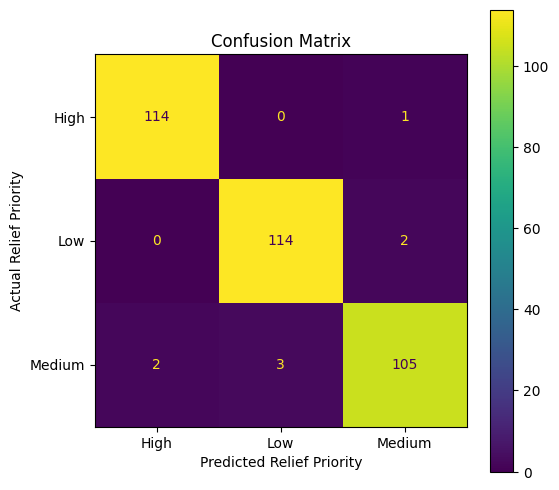

In [11]:
y_test_labels=target_variable_encoder.inverse_transform(y_test)
y_pred_labels=target_variable_encoder.inverse_transform(y_pred)

cm=confusion_matrix(y_test_labels,y_pred_labels,labels=target_variable_encoder.classes_)

cm_display=ConfusionMatrixDisplay( confusion_matrix=cm, display_labels=target_variable_encoder.classes_)
fig, ax = plt.subplots(figsize=(6,6))
cm_display.plot(ax=ax, cmap="viridis", colorbar=True)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Relief Priority")
plt.ylabel("Actual Relief Priority")
plt.show()



### Feature Importance Analysis

#### Overview

Feature importance analysis was conducted to identify which engineered features contributed the most to the XGBoost classifier when predicting the **Relief Priority** of disaster events. XGBoost computes feature importance by measuring how much each feature contributes to reducing the model's prediction error during decision tree construction.

Features with higher importance scores have a greater influence on the model's predictions, while features with lower scores contribute less to the classification process.

---

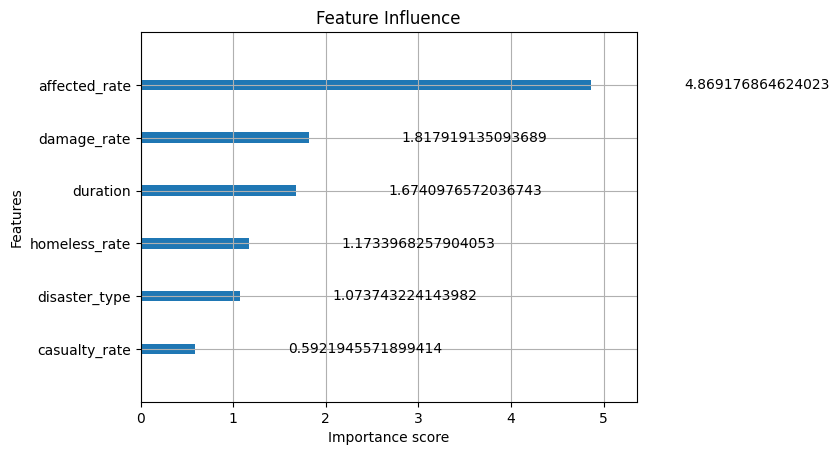

In [12]:
plot_importance(model, importance_type="gain")
plt.title("Feature Influence")
plt.show()



#### Results

The computed feature importance scores are summarized below.

| Rank | Feature | Importance Score |
|------|----------------|----------------:|
| 1 | Affected Rate | 77.18 |
| 2 | Duration Score | 14.52 |
| 3 | Homeless Rate | 11.06 |
| 4 | Damage Rate | 7.43 |
| 5 | Casualty Rate | 2.78 |

---

#### Interpretation

The results indicate that **Affected Rate** is the most influential feature, with an importance score of **77.18**. This suggests that the proportion of the population affected by a disaster is the strongest indicator used by the model when determining disaster relief priority. Since relief operations are primarily intended to support affected communities, this result aligns well with practical disaster management principles.

The **Duration Score** is the second most important feature. Longer-lasting disasters generally require prolonged humanitarian assistance and resource allocation, making disaster duration an important factor in prioritizing relief efforts.

The **Homeless Rate** also contributes substantially to the model. A higher proportion of displaced individuals often reflects severe infrastructure damage and increased demand for emergency shelter, food, and medical assistance.

Although **Damage Rate** contributes to the prediction, its influence is comparatively lower than the previous features. This suggests that while economic losses are relevant, the model places greater emphasis on direct human impact when estimating relief priorities.

Finally, **Casualty Rate** received the lowest importance score among the engineered features. This does not imply that casualties are unimportant in disaster response; rather, within this dataset, casualty information contributed less to distinguishing relief priority compared with the proportion of affected or displaced populations.

---

#### Conclusion

The feature importance analysis demonstrates that the XGBoost classifier primarily relies on human impact indicators when predicting disaster relief priority. In particular, the **Affected Rate** dominates the prediction process, followed by **Duration Score** and **Homeless Rate**. These findings suggest that population-based impact measures provide the strongest predictive signals for prioritizing disaster relief resources in the proposed system.

### 1.6 Model Testing


In [13]:
new_disaster = pd.DataFrame({
    "disaster_type": [1],
    "affected_rate": [0.3],
    "homeless_rate": [0.1],
    "casualty_rate": [0.1],
    "damage_rate": [0.1],
    "duration": [0.1]
})


prediction=model.predict(new_disaster)
print(prediction[0])
priority=target_variable_encoder.inverse_transform(prediction)[0]
print(priority)

0
High


### 1.7 Saving Model
Saving the trained model,the disaster type label encoder ald also the target variable encoder in models folder


In [ ]:
joblib.dump(model,"../../model_weights/disaster_relief_optimizer.pkl")
joblib.dump(target_variable_encoder,"../../model_weights/label_encoder.pkl")
joblib.dump(disaster_type_encoder,"../../model_weights/disaster_type_encoder.pkl")

['../../model_weights/disaster_type_encoder.pkl']